<a href="https://colab.research.google.com/github/kritikamandale/Python_is_a_language/blob/main/Day2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#oops problem Solution

# Base Class: Resource

class Resource:
    def __init__(self, name, total_available, renewable):
        self._name = name
        self._total_available = total_available
        self._remaining = total_available
        self._renewable = renewable
        self._total_used = 0

    def update_availability(self, amount):
        if amount <= 0:
            raise ValueError("Usage amount must be positive.")

        if amount > self._remaining:
            raise ValueError(f"Not enough {self._name} available.")

        self._remaining -= amount
        self._total_used += amount

    def report_usage(self):
        print(f"Resource: {self._name}")
        print(f"Renewable: {self._renewable}")
        print(f"Total Available: {self._total_available}")
        print(f"Used: {self._total_used}")
        print(f"Remaining: {self._remaining}")
        print("-" * 30)

    def is_renewable(self):
        return self._renewable

    def get_used_amount(self):
        return self._total_used

    def get_name(self):
        return self._name



# Subclasses

class WaterResource(Resource):
    pass


class EnergyResource(Resource):
    pass


class WasteResource(Resource):
    pass


# Consumer Class

class Consumer:
    def __init__(self, consumer_id, name):
        self.consumer_id = consumer_id
        self.name = name
        self.assigned_resources = []
        self.usage_record = {}

    def assign_resource(self, resource):
        self.assigned_resources.append(resource)
        self.usage_record[resource.get_name()] = 0

    def use_resource(self, resource, amount):
        if resource not in self.assigned_resources:
            raise ValueError("Resource not assigned to this consumer.")

        resource.update_availability(amount)
        self.usage_record[resource.get_name()] += amount

    def generate_usage_report(self):
        print(f"Usage Report for Consumer: {self.name}")
        for res, amt in self.usage_record.items():
            print(f"{res}: {amt}")
        print("-" * 30)


# Sustainability Report
def sustainability_report(resources, threshold=0.8):
    renewable_usage = 0
    non_renewable_usage = 0

    print("\n=== Sustainability Report ===")

    for res in resources:
        used = res.get_used_amount()
        if res.is_renewable():
            renewable_usage += used
        else:
            non_renewable_usage += used

        usage_ratio = used / res._total_available
        if usage_ratio > threshold:
            print(f"⚠ ALERT: High usage detected for {res.get_name()}")

    print(f"Total Renewable Usage: {renewable_usage}")
    print(f"Total Non-Renewable Usage: {non_renewable_usage}")
    print("=============================\n")


# -----------------------------
# Sample Interaction
# -----------------------------
if __name__ == "__main__":
    # Create Resources
    water = WaterResource("Water", 1000, True)
    energy = EnergyResource("Electricity", 500, False)
    waste = WasteResource("Waste Capacity", 300, False)

    # Create Consumers
    c1 = Consumer(1, "Household A")
    c2 = Consumer(2, "Municipal Office")

    # Assign Resources
    c1.assign_resource(water)
    c1.assign_resource(energy)

    c2.assign_resource(water)
    c2.assign_resource(waste)

    # Resource Consumption
    c1.use_resource(water, 200)
    c1.use_resource(energy, 100)

    c2.use_resource(water, 300)
    c2.use_resource(waste, 150)

    # Reports
    c1.generate_usage_report()
    c2.generate_usage_report()

    water.report_usage()
    energy.report_usage()
    waste.report_usage()

    sustainability_report([water, energy, waste])

Usage Report for Consumer: Household A
Water: 200
Electricity: 100
------------------------------
Usage Report for Consumer: Municipal Office
Water: 300
Waste Capacity: 150
------------------------------
Resource: Water
Renewable: True
Total Available: 1000
Used: 500
Remaining: 500
------------------------------
Resource: Electricity
Renewable: False
Total Available: 500
Used: 100
Remaining: 400
------------------------------
Resource: Waste Capacity
Renewable: False
Total Available: 300
Used: 150
Remaining: 150
------------------------------

=== Sustainability Report ===
Total Renewable Usage: 500
Total Non-Renewable Usage: 250



In [2]:
import seaborn as sns

In [3]:
tip_df = sns.load_dataset('tips')
tip_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [7]:
tip_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

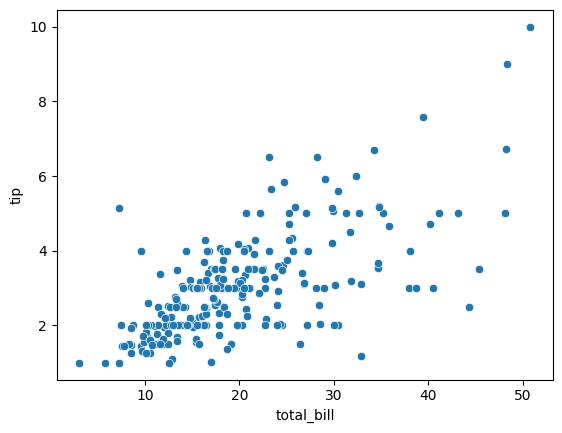

In [5]:
sns.scatterplot(x= 'total_bill', y = 'tip', data = tip_df)

<Axes: xlabel='total_bill', ylabel='tip'>

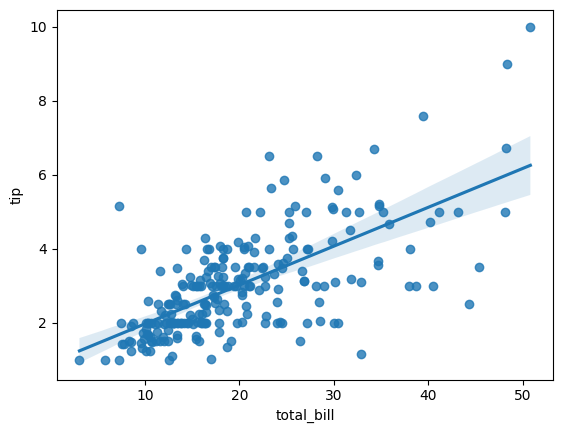

In [8]:
sns.regplot(x= 'total_bill', y = 'tip', data = tip_df)
#best fit line that justify the data set

In [11]:
# y = m*x + c
# y = 1.5*x + 1.1

In [29]:
import pandas as pd
energy_df = pd.read_csv('appliance_energy.csv')
energy_df.head()

,Temperature (°C),Energy Consumption (kWh)
0,22.490802,2.292604
1,34.014286,3.251925
2,29.639879,3.009868
3,26.973170,1.703533
4,18.120373,1.702201


In [30]:
#rename the columns
energy_df.rename(columns = {"Temperature (°C)" : 'temperature',"Energy Consumption (kWh)" : 'energy_consumption'},inplace = True)

In [31]:
energy_df.head()

,temperature,energy_consumption
0,22.490802,2.292604
1,34.014286,3.251925
2,29.639879,3.009868
3,26.973170,1.703533
4,18.120373,1.702201


In [32]:
energy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperature         100 non-null    float64
 1   energy_consumption  100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [33]:
energy_df.isna().sum()

,0
temperature,0
energy_consumption,0


<Axes: xlabel='temperature', ylabel='energy_consumption'>

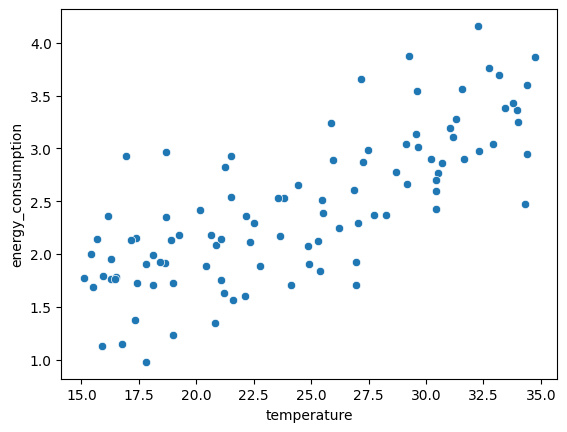

In [34]:
sns.scatterplot(x = 'temperature', y = 'energy_consumption', data = energy_df)


In [35]:
#identifying input and output features
x = energy_df[['temperature']]
y = energy_df['energy_consumption']

In [36]:
x[:5]

,temperature
0,22.490802
1,34.014286
2,29.639879
3,26.973170
4,18.120373


In [37]:
y[:5]

,energy_consumption
0,2.292604
1,3.251925
2,3.009868
3,1.703533
4,1.702201


In [38]:
# x,y, z= 10, "xyz", 20
# print (z)

In [39]:
#split the data into training and testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [42]:
x.shape

(100, 1)

In [43]:
y.shape

(100,)

In [44]:
y_train.shape

(80,)

In [45]:
x_train[:5]

,temperature
55,33.437485
88,32.744255
26,18.993476
42,15.687770
69,34.737739


In [46]:
#selecting the algorithm
from sklearn.linear_model import LinearRegression

In [47]:
my_model = LinearRegression()

In [48]:
#train the model
my_model.fit(x_train, y_train)

LinearRegression()

In [49]:
#test the model
y_pred = my_model.predict(x_test)

In [50]:
y_pred[:5]

array([1.6858187 , 3.18154068, 2.96097494, 2.76354868, 2.0370856 ])

In [51]:
y_test[:5]

,energy_consumption
83,1.955394
53,3.037917
70,2.426014
45,2.370351
44,2.413076


In [53]:
#evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

In [56]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [62]:
print(f"Mean Squared Error: {mse:.2}")
print(f"R-squared: {r2:.2}")

Mean Squared Error: 0.16
R-squared: 0.61


In [63]:
my_model.intercept_

np.float64(0.22196391661907633)

In [64]:
my_model.coef_

array([0.08996618])

In [65]:
import matplotlib.pyplot as plt

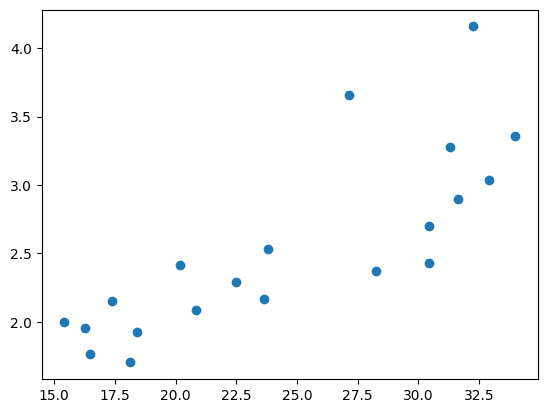

In [66]:
plt.scatter(x_test, y_test, label = "Test")

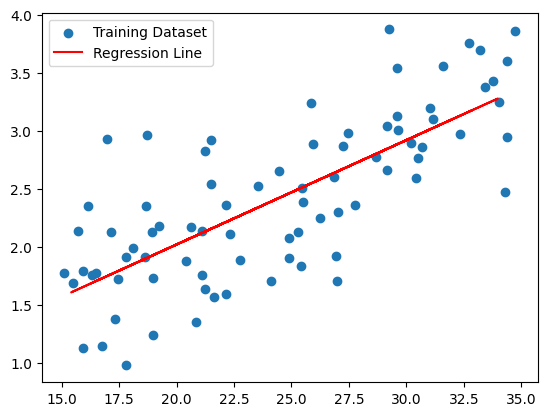

In [70]:
plt.scatter(x_train, y_train, label = "Training Dataset")
plt.plot(x_test, y_pred, label = "Regression Line", color = 'red')
plt.legend()
plt.show()

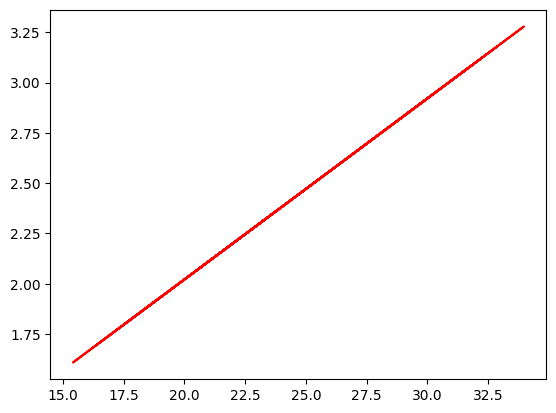

In [68]:
plt.plot(x_test, y_pred, label = "Regression Line", color = 'red')